In [12]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# import data

data = pd.read_csv("../data/xdr_data.csv")

data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150001 entries, 0 to 150000
Data columns (total 55 columns):
 #   Column                                    Non-Null Count   Dtype  
---  ------                                    --------------   -----  
 0   Bearer Id                                 149010 non-null  float64
 1   Start                                     150000 non-null  object 
 2   Start ms                                  150000 non-null  float64
 3   End                                       150000 non-null  object 
 4   End ms                                    150000 non-null  float64
 5   Dur. (ms)                                 150000 non-null  float64
 6   IMSI                                      149431 non-null  float64
 7   MSISDN/Number                             148935 non-null  float64
 8   IMEI                                      149429 non-null  float64
 9   Last Location Name                        148848 non-null  object 
 10  Avg RTT DL (ms)     

,Bearer Id,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Last Location Name,...,Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
0,1.311448e+19,4/4/2019 12:01,770.0,4/25/2019 14:35,662.0,1823652.0,2.082014e+14,3.366496e+10,3.552121e+13,9.16456699548519E+015,...,15854611.0,2501332.0,8198936.0,9656251.0,278082303.0,14344150.0,171744450.0,8814393.0,36749741.0,308879636.0
1,1.311448e+19,4/9/2019 13:04,235.0,4/25/2019 8:15,606.0,1365104.0,2.082019e+14,3.368185e+10,3.579401e+13,L77566A,...,20247395.0,19111729.0,18338413.0,17227132.0,608750074.0,1170709.0,526904238.0,15055145.0,53800391.0,653384965.0
2,1.311448e+19,4/9/2019 17:42,1.0,4/25/2019 11:58,652.0,1361762.0,2.082003e+14,3.376063e+10,3.528151e+13,D42335A,...,19725661.0,14699576.0,17587794.0,6163408.0,229584621.0,395630.0,410692588.0,4215763.0,27883638.0,279807335.0
3,1.311448e+19,4/10/2019 0:31,486.0,4/25/2019 7:36,171.0,1321509.0,2.082014e+14,3.375034e+10,3.535661e+13,T21824A,...,21388122.0,15146643.0,13994646.0,1097942.0,799538153.0,10849722.0,749039933.0,12797283.0,43324218.0,846028530.0
4,1.311448e+19,4/12/2019 20:10,565.0,4/25/2019 10:40,954.0,1089009.0,2.082014e+14,3.369980e+10,3.540701e+13,D88865A,...,15259380.0,18962873.0,17124581.0,415218.0,527707248.0,3529801.0,550709500.0,13910322.0,38542814.0,569138589.0


In [14]:
df = data.copy()
df.columns

Index(['Bearer Id', 'Start', 'Start ms', 'End', 'End ms', 'Dur. (ms)', 'IMSI',
       'MSISDN/Number', 'IMEI', 'Last Location Name', 'Avg RTT DL (ms)',
       'Avg RTT UL (ms)', 'Avg Bearer TP DL (kbps)', 'Avg Bearer TP UL (kbps)',
       'TCP DL Retrans. Vol (Bytes)', 'TCP UL Retrans. Vol (Bytes)',
       'DL TP < 50 Kbps (%)', '50 Kbps < DL TP < 250 Kbps (%)',
       '250 Kbps < DL TP < 1 Mbps (%)', 'DL TP > 1 Mbps (%)',
       'UL TP < 10 Kbps (%)', '10 Kbps < UL TP < 50 Kbps (%)',
       '50 Kbps < UL TP < 300 Kbps (%)', 'UL TP > 300 Kbps (%)',
       'HTTP DL (Bytes)', 'HTTP UL (Bytes)', 'Activity Duration DL (ms)',
       'Activity Duration UL (ms)', 'Dur. (ms).1', 'Handset Manufacturer',
       'Handset Type', 'Nb of sec with 125000B < Vol DL',
       'Nb of sec with 1250B < Vol UL < 6250B',
       'Nb of sec with 31250B < Vol DL < 125000B',
       'Nb of sec with 37500B < Vol UL',
       'Nb of sec with 6250B < Vol DL < 31250B',
       'Nb of sec with 6250B < Vol UL < 37500B',


In [15]:
# Rename the columns
    #DL : Downnlink ; UL: Uplink ; TP: Througput
col_names = ["Bearer_Id", "Start", "Start_ms", "End", "End_ms", "Duration(ms)", "IMSI", "MSISDN", "IMEI",
 "Last_location", "Avg_RTT_DL(ms)", "Avg_RTT_DU(ms)", "Avg_Bearer_TP_DL(kbps)", 
 "Avg_Bearer_TP_UL(kbps)", "TCP_DL_Retrans_vol(bytes)", "TCP_UL_Retrans_vol(bytes)", "DL_TP_<50kpbs(%)",
 "DL_TP_betw(50kpbs,250kpbs)%", "DL_TP_betw(250kpbs,1Mbps)%", "DL_TP_>1Mbps(%)", "UL_TP_<10kpbs(%)",
 "UL_TP_betw(10kpbs,50kpbs)%", "UL_TP_betw(50kpbs,300kpbs)%", "UL_TP_>300Kbps(%)", "HTTP_DL(Bytes)",
 "HTTP_UL(Bytes)", "Activity_duration_DL(ms)", "Activity_duration_UL(ms)", "Total_duration_xDR(ms)",
 "Handset_manufacturer", "Handset_type", "Nb(sec)_125000B<Vol_DL", "NB(sec)_Vol_UL_betw(1250B,6250B)",
 "NB(sec)_Vol_DL_betw(31250B,125000B)", "Nb(sec)_37500B<Vol_UL", "NB(sec)_Vol_DL_betw(6250B,31250B)",
 "NB(sec)_Vol_UL_betw(6250B,37500B)", "Nb(sec)_6250B>Vol_DL", "Nb(sec)_1250B>Vol_UL", 
 "Social_media_DL(bytes)", "Social_media_UL(bytes)", "Google_DL(bytes)", "Google_UL(bytes)",
 "Email_DL(bytes)", "Email_UL(bytes)", "Youtube_DL(bytes)", "Youtube_UL(bytes)", "Netflix_DL(bytes)",
 "Netflix_UL(bytes)", "Gaming_DL(bytes)", "Gaming_UL(bytes)", "Other_DL(bytes)", "Other_UL(bytes)",
  "Total_UL(bytes)", "Total_DL(bytes)"]

df.columns = col_names
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150001 entries, 0 to 150000
Data columns (total 55 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   Bearer_Id                            149010 non-null  float64
 1   Start                                150000 non-null  object 
 2   Start_ms                             150000 non-null  float64
 3   End                                  150000 non-null  object 
 4   End_ms                               150000 non-null  float64
 5   Duration(ms)                         150000 non-null  float64
 6   IMSI                                 149431 non-null  float64
 7   MSISDN                               148935 non-null  float64
 8   IMEI                                 149429 non-null  float64
 9   Last_location                        148848 non-null  object 
 10  Avg_RTT_DL(ms)                       122172 non-null  float64
 11  Avg_RTT_DU(ms

## EDA

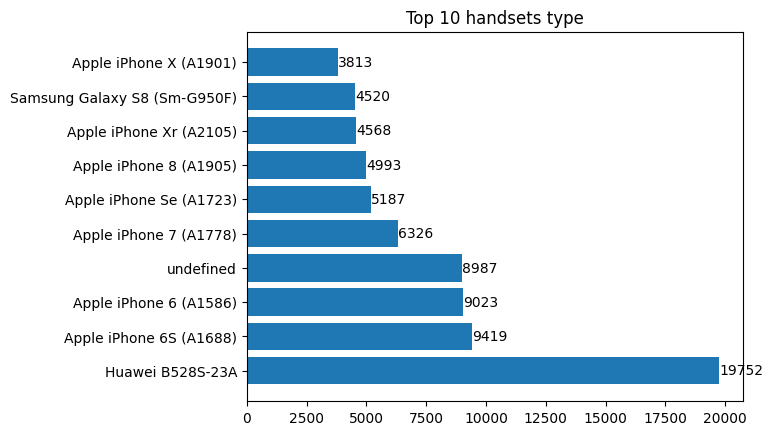

In [41]:
# Handsets used by customers (Top 10)
handsets = df["Handset_type"].value_counts().head(10)

plt.barh(handsets.index, handsets.values)
for i, value in enumerate(handsets.values):
    plt.text(value + 10, i, str(value), va='center')
    #plt.text(value / 2, i, str(value), ha='center', va='center')

plt.title("Top 10 handsets type")
plt.show()


Text(0.5, 1.0, 'Top 3 handsets manufacturer')

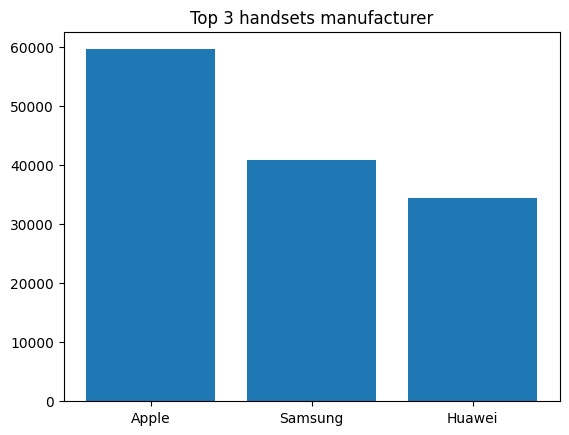

In [54]:
# Handsets manufacturer (Top3)
manufac = df["Handset_manufacturer"].value_counts().head(3)

plt.bar(manufac.index, manufac.values)
plt.title("Top 3 handsets manufacturer")

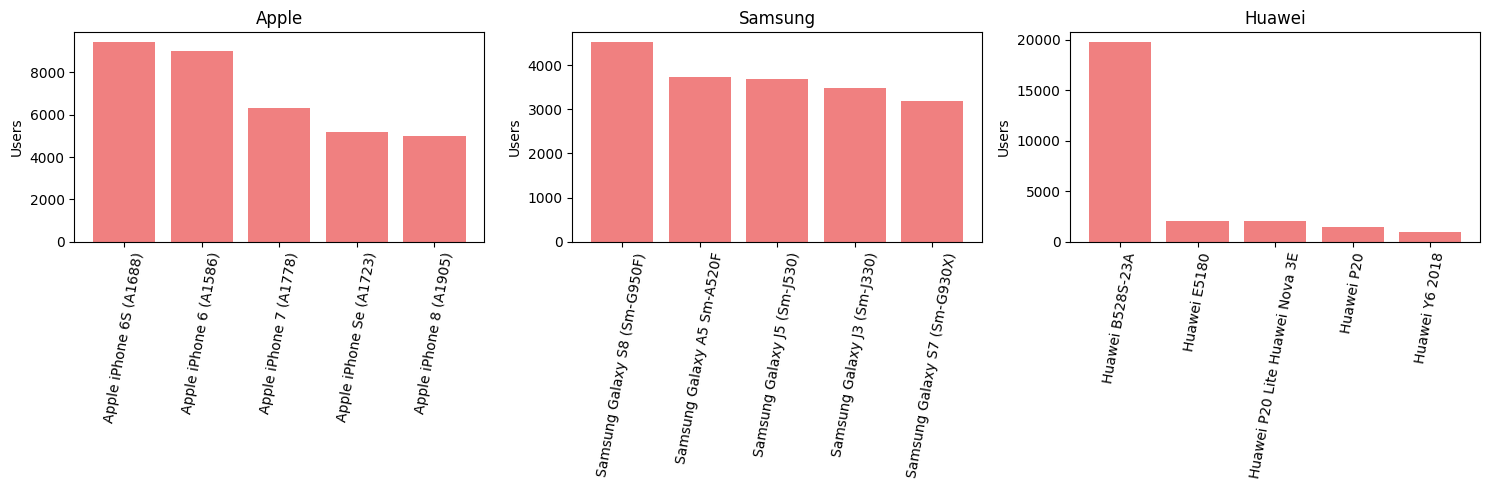

In [73]:
# Top 5 handsets per top 3 handset manufacturer

plt.figure(figsize=(15, 5))

for idx, manu in enumerate(manufac.index, 1): 
    dt = df[df["Handset_manufacturer"] == manu]
    types = dt["Handset_type"].value_counts().head(5)

    plt.subplot(1, 3, idx)
    plt.bar(types.index, types.values, color='lightcoral')
    plt.title(manu)
    plt.xticks(rotation=80)
    plt.ylabel("Users")

plt.tight_layout()
plt.show()


### Interpretation
- Apple:
    The iPhone 6S (A1688) and iPhone 6 (A1586) dominate usage. These are relatively older models, indicating Apple users in this market segment may retain their devices longer.

- Samsung:
    A more diverse but balanced distribution across mid-range models like Galaxy S8, A5, J5, J3. This indicates a broader spread of price sensitivity and usage habits in the Samsung segment.

- Huawei:
    The Huawei B528S-23A(a router-type device) is by far the most used, likely for data usage or fixed wireless access. The rest of the Huawei models have very low individual penetration, showing limited handset diversity or user base.

### Recommandation to the marketing team
- Apple segment:
    Implement loyalty programs, as Apple users tend to stick longer to their phones. These loyalty pragrams can reward a device upgrade for the best customers.

- Samsung segment:
    Target these users for cross-selling accessories or device insurance.

- Huawei segment:
    Capitalize on the heavy usage of the Huawei B528S-23A by offering data bundle packages specifically tailored for home/office use. Explore partnerships or bundles targeting home internet users rather than mobile handset users.